[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cookbook-ms/Chung_Lu_Chain-synthesizer/blob/main/examples/colab/GenLoadSettings_colab.ipynb)


# Generation Capacities and Load Settings

In previous two notebooks, we saw how the raw grid topology and the bus types can be synthetically generated. 

In this notebook, we move futher in the synthetic power grid data generation by looking into how to generate capacity values for generator buses and assign load values for load buses. 

## Basics

In [1]:
import sys
import os
import networkx as nx
from collections import Counter

from powergrid_synth.generator import PowerGridGenerator
from powergrid_synth.input_configurator import InputConfigurator
from powergrid_synth.bus_type_allocator import BusTypeAllocator
from powergrid_synth.capacity_allocator import CapacityAllocator
from powergrid_synth.load_allocator import LoadAllocator
from powergrid_synth.generation_dispatcher import GenerationDispatcher
from powergrid_synth.transmission import TransmissionLineAllocator
from powergrid_synth.visualization import GridVisualizer

## Synthetic raw topology generation & Bus Type Assignment

We use the previous notebook, [BusTypeAssignment.ipynb](BusTypeAssignment.ipynb), for this.

We refer readers to that notebook for the defined python variables.


[1] Configuring 3-Level Hierarchy...
Generating Level 0: DGLN distribution (Avg=4.0)
Generating Level 1: DPL distribution (Avg=3.0)
Generating Level 2: DGLN distribution (Avg=2.0)
Generating Transformers 0<->1: k-Stars Model
4.15
Generating Transformers 1<->2: k-Stars Model
4.15

[2] Generating Topology...
--- Starting Generation for 3 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 21, Edges: 28
Generating Level 1...
  -> Level 1 Complete. Nodes: 26, Edges: 20
Generating Level 2...
  -> Level 2 Complete. Nodes: 12, Edges: 11
Generating Transformer Connections...
  -> Connecting Level 0 <-> Level 1
  -> Connecting Level 1 <-> Level 2
Filtering for Largest Connected Component (LCC)...
  -> Kept 52 nodes (removed 7 isolated nodes)
Grid Generated: 52 nodes, 64 edges

[3] Visualizing Full Grid Topology...
Calculating layout 'kamada_kawai'...


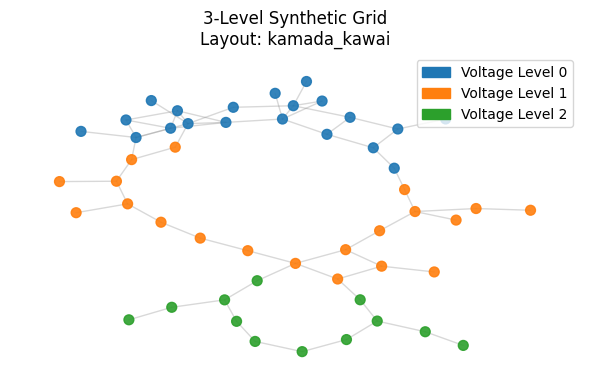


[3] Visualizing Sub-Grid Topology...
Calculating layout 'kamada_kawai'...
Calculating layout 'kamada_kawai'...
Calculating layout 'kamada_kawai'...


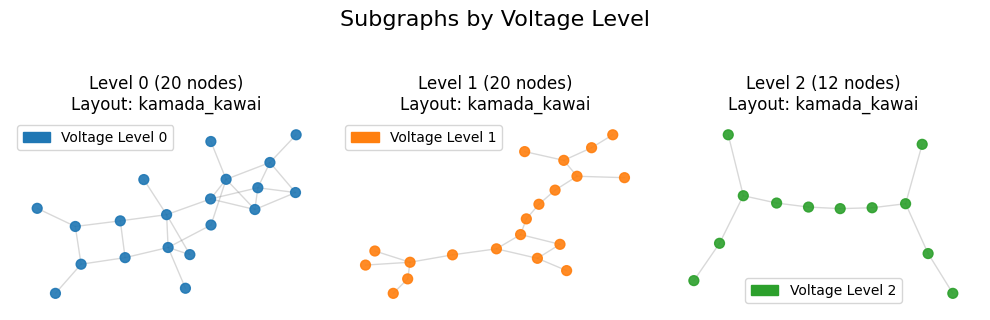


[4] Running Hierarchical Analysis...

GLOBAL GRID ANALYSIS

=== Power Grid Topological Analysis ===
Nodes: 52
Edges: 64
Density: 0.048265
Connected: Yes
Diameter: 15
Avg Shortest Path Length: 6.6523
Avg Local Clustering Coeff: 0.0647

Plotting Global Degree Distribution...


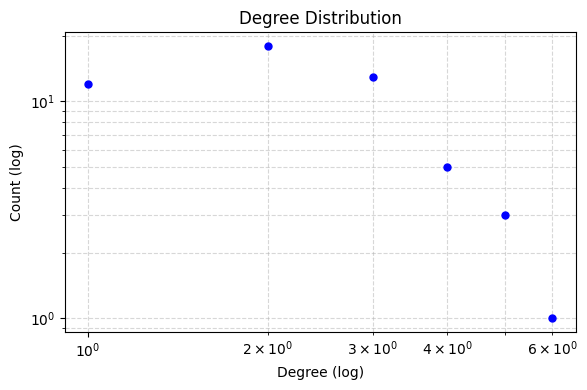


ANALYSIS FOR VOLTAGE LEVEL 0

=== Power Grid Topological Analysis ===
Nodes: 20
Edges: 28
Density: 0.147368
Connected: Yes
Diameter: 7
Avg Shortest Path Length: 3.1105
Avg Local Clustering Coeff: 0.1733


ANALYSIS FOR VOLTAGE LEVEL 1

=== Power Grid Topological Analysis ===
Nodes: 20
Edges: 20
Density: 0.105263
Connected: Yes
Diameter: 12
Avg Shortest Path Length: 4.9895
Avg Local Clustering Coeff: 0.0000


ANALYSIS FOR VOLTAGE LEVEL 2

=== Power Grid Topological Analysis ===
Nodes: 12
Edges: 11
Density: 0.166667
Connected: Yes
Diameter: 9
Avg Shortest Path Length: 3.8485
Avg Local Clustering Coeff: 0.0000

Plotting Combined Figure for 3 Levels (Log Scale: True)...


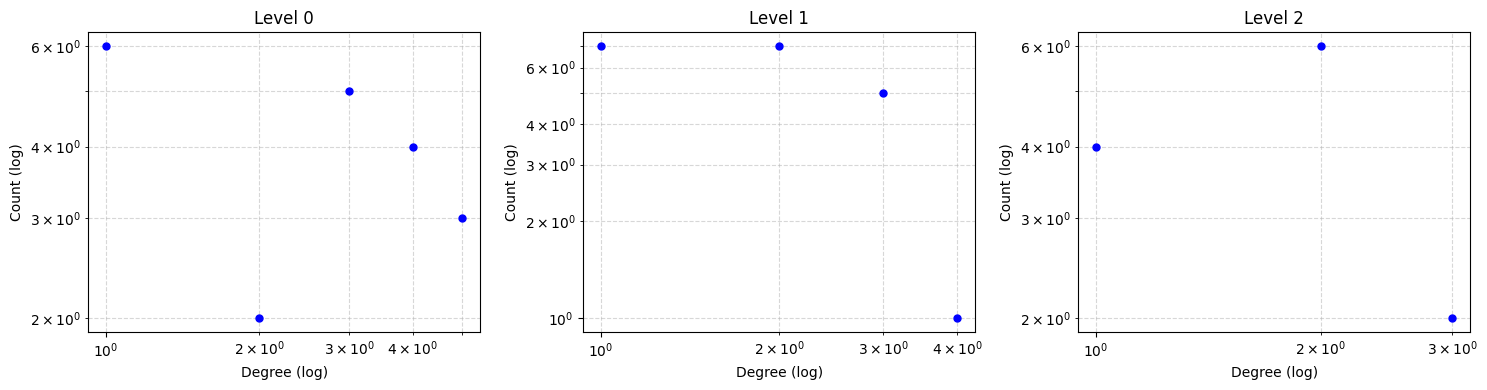

Analysis Complete.
Starting Bus Type Allocation (N=52, M=64)...
  Target Entropy Score (W*): 158.3352, Std Dev: 3.8665
  Iter 0: Best Error = 0.348913
  Converged at iteration 1. Error: 0.003277 < Criteria: 0.003867


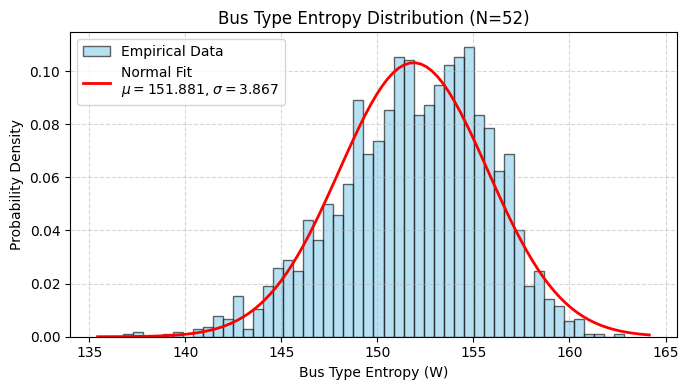

-----> Assignment Complete:
       Generators: 14 (26.9%)
       Loads:      24 (46.2%)
       Connectors: 14 (26.9%)

[5] Visualizing Bus Types & Edge Styles...
Calculating layout 'kamada_kawai' for bus types...


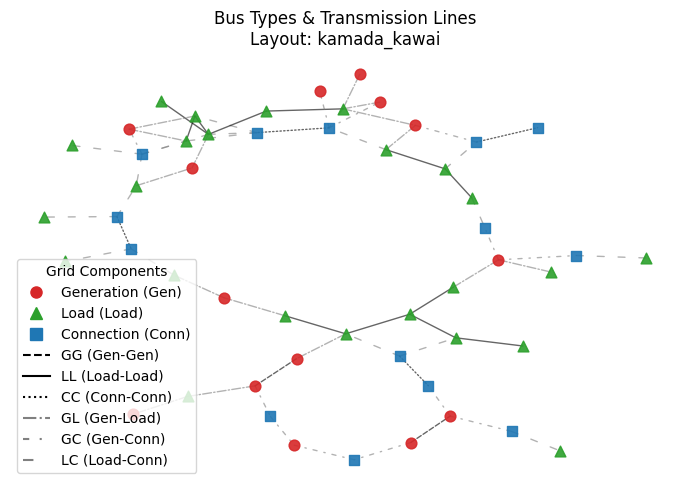

In [2]:
%run BusTypeAssignment.ipynb

## Generation Capacities

In [3]:
print("\n[6] Allocating Capacity...")
cap_allocator = CapacityAllocator(grid_graph)
capacities = cap_allocator.allocate()
total_gen = sum(capacities.values())
print(f"Total Generation: {total_gen:.2f} MW")
# Attach to graph
nx.set_node_attributes(grid_graph, capacities, name="pg_max")



[6] Allocating Capacity...
Allocating Capacity for 14 generators.
Total System Capacity Target: 3772.13 MW using Reference System 1
Total Generation: 3772.13 MW


In [4]:
# Check top 10 generators
sorted_gens = sorted(capacities.items(), key=lambda x: x[1], reverse=True)
print("\nTop 5 Generators by Capacity:")
for node, cap in sorted_gens[:10]:
    print(f"  Node {node}: {cap:.2f} MW (Degree: {grid_graph.degree(node)})")


Top 5 Generators by Capacity:
  Node 14: 796.57 MW (Degree: 1)
  Node 8: 677.89 MW (Degree: 1)
  Node 29: 510.88 MW (Degree: 2)
  Node 46: 508.80 MW (Degree: 2)
  Node 18: 207.06 MW (Degree: 3)
  Node 39: 200.95 MW (Degree: 2)
  Node 50: 198.14 MW (Degree: 1)
  Node 47: 159.65 MW (Degree: 3)
  Node 16: 125.99 MW (Degree: 2)
  Node 9: 92.24 MW (Degree: 3)


## Load Settings

In [5]:
print("\n[7] Allocating Loads ...")
load_allocator = LoadAllocator(grid_graph, ref_sys_id=1)
loads = load_allocator.allocate(loading_level='H')

# Attach to graph (attribute 'pl' for active power load)
nx.set_node_attributes(grid_graph, loads, name="pl")

total_load = sum(loads.values())
print(f"Total Load: {total_load:.2f} MW")

print(f"System Loading: {total_load/total_gen:.1%}")


[7] Allocating Loads ...
Allocating Loads for 24 load buses.
Total System Load Target: 2645.09 MW (Level: H)
Total Load: 2645.09 MW
System Loading: 70.1%


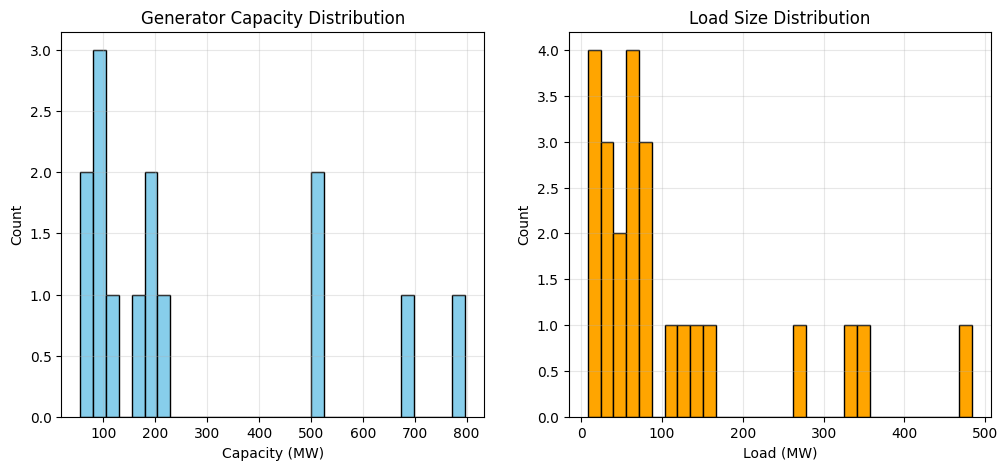

In [6]:
# Plot Distribution
load_vals = list(loads.values())

if load_vals:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 2)
    plt.hist(load_vals, bins=30, color='orange', edgecolor='black')
    plt.title("Load Size Distribution")
    plt.xlabel("Load (MW)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    
# Plot Distribution
caps = list(capacities.values())
if caps:
    plt.subplot(1, 2, 1)
    plt.hist(caps, bins=30, color='skyblue', edgecolor='black')
    plt.title("Generator Capacity Distribution")
    plt.xlabel("Capacity (MW)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()